In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kathuman/housing")

print("Path to dataset files:", path)

100%|██████████| 400k/400k [00:00<00:00, 1.03MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/kathuman/housing/versions/1


In [9]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/housing.csv")

print(df.head())
print(df.info())

# -------------------------------
# 1. Handle Missing Values
# -------------------------------

print("\nMissing values:\n", df.isnull().sum())

# Fill numerical columns with mean
df.fillna(df.mean(numeric_only=True), inplace=True)

# Fill categorical columns with mode
for col in df.select_dtypes(include='object'):
    df[col] = df[col].fillna(df[col].mode()[0])

# -------------------------------
# 2. Encode Categorical Variable
# -------------------------------

le = LabelEncoder()
df['ocean_proximity'] = le.fit_transform(df['ocean_proximity'])

# -------------------------------
# 3. Feature Selection
# -------------------------------

X = df[['longitude', 'latitude', 'housing_median_age',
        'total_rooms', 'total_bedrooms', 'population',
        'households', 'median_income', 'ocean_proximity']]

y = df['median_house_value']

# -------------------------------
# 4. Train-Test Split
# -------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 5. Train Model
# -------------------------------

model = LinearRegression()
model.fit(X_train, y_train)

# -------------------------------
# 6. Evaluate Model
# -------------------------------

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

# -------------------------------
# 7. Feature Importance
# -------------------------------

coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
print("\nFeature Coefficients:\n", coefficients)

# -------------------------------
# 8. Predict New House Price
# -------------------------------

# See available categories
print("\nOcean proximity categories:", le.classes_)

# Example input (adjust values as needed)
new_house = pd.DataFrame({
    'longitude': [-122.23],
    'latitude': [37.88],
    'housing_median_age': [20],
    'total_rooms': [2000],
    'total_bedrooms': [400],
    'population': [1000],
    'households': [300],
    'median_income': [5.0],
    'ocean_proximity': [le.transform([le.classes_[0]])[0]]
})

predicted_price = model.predict(new_house)

print("\nPredicted Price:", predicted_price[0])

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639

In [12]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv("/content/drive/MyDrive/spam.csv")

print(df.head())
print(df.info())


df['Category'] = df['Category'].map({'ham': 0, 'spam': 1})

df['Message'] = df['Message'].fillna("")


vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)

X = vectorizer.fit_transform(df['Message'])
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

def predict_email(text):
    text_vec = vectorizer.transform([text])
    prediction = model.predict(text_vec)[0]

    return "Spam" if prediction == 1 else "Not Spam"

email1 = "Congratulations! You won a free ticket. Click now!"
email2 = "Hey, are we still meeting today?"

print("\nEmail 1:", predict_email(email1))
print("Email 2:", predict_email(email2))

  Category                                            Message
0      ham  Go until jurong point, crazy.. Available only ...
1      ham                      Ok lar... Joking wif u oni...
2     spam  Free entry in 2 a wkly comp to win FA Cup fina...
3      ham  U dun say so early hor... U c already then say...
4      ham  Nah I don't think he goes to usf, he lives aro...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Category  5572 non-null   object
 1   Message   5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Accuracy: 0.9820627802690582

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       966
           1       1.00      0.87      0.93       149

    accuracy                           0.98      1115
   macro avg       0.99      0.93      0.96      11

In [17]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.metrics import accuracy_score, classification_report

df = pd.read_csv(
    "/content/drive/MyDrive/OnlineRetail.csv",
    encoding='ISO-8859-1',
    engine='python'
)

print(df.head())
print(df.info())

df = df.dropna(subset=['CustomerID'])

df = df[df['Quantity'] > 0]

df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

customer_df = df.groupby('CustomerID').agg({
    'TotalPrice': 'sum',
    'InvoiceNo': 'nunique',
    'Quantity': 'sum'
}).reset_index()

customer_df.rename(columns={
    'TotalPrice': 'total_spending',
    'InvoiceNo': 'visits',
    'Quantity': 'total_items'
}, inplace=True)

print("\nCustomer Dataset:\n", customer_df.head())

threshold = customer_df['total_spending'].quantile(0.70)

customer_df['customer_type'] = np.where(
    customer_df['total_spending'] >= threshold, 1, 0
)

print("\nLabel distribution:\n", customer_df['customer_type'].value_counts())

X = customer_df[['total_spending', 'visits', 'total_items']]
y = customer_df['customer_type']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

svm_model = SVC(kernel='linear')
svm_model.fit(X_train_scaled, y_train)

svm_pred = svm_model.predict(X_test_scaled)


tree_model = DecisionTreeClassifier(max_depth=3)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

rules = export_text(tree_model, feature_names=list(X.columns))

print("\nDECISION TREE RULES:\n")
print(rules)


print("\n==================== SVM RESULTS ====================")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

print("\n================ DECISION TREE RESULTS ================")
print("Accuracy:", accuracy_score(y_test, tree_pred))
print(classification_report(y_test, tree_pred))

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('/content/drive/MyDrive/Mall_Customers.csv')

df.columns = df.columns.str.strip()

print(df.columns)

df_features = df.drop(columns=['CustomerID'])

if 'Gender' in df_features.columns:
    df_features['Gender'] = df_features['Gender'].map({'Male': 0, 'Female': 1})
elif 'Genre' in df_features.columns:
    df_features['Genre'] = df_features['Genre'].map({'Male': 0, 'Female': 1})

kmeans_no_scale = KMeans(n_clusters=5, random_state=42)
df['Cluster_No_Scaling'] = kmeans_no_scale.fit_predict(df_features)

scaler = StandardScaler()

scaled_features = df_features.copy()

cols_to_scale = scaled_features.columns.tolist()
if 'Age' in cols_to_scale:
    cols_to_scale.remove('Age')

scaled_features[cols_to_scale] = scaler.fit_transform(scaled_features[cols_to_scale])

kmeans_scaled = KMeans(n_clusters=5, random_state=42)
df['Cluster_With_Scaling'] = kmeans_scaled.fit_predict(scaled_features)

print(df.head())

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster_No_Scaling  Cluster_With_Scaling  
0                   2                     2  
1                   2                     2  
2                   0                     2  
3                   2                     2  
4                   0                     1  


In [18]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'vehicle_serial_no': [5, 3, 8, 2, 4, 7, 6, 10, 1, 9],
    'mileage': [150000, 120000, 250000, 80000, 100000, 220000, 180000, 300000, 75000, 280000],
    'fuel_efficiency': [15, 18, 10, 22, 20, 12, 16, 8, 24, 9],
    'maintenance_cost': [5000, 4000, 7000, 2000, 3000, 6500, 5500, 8000, 1500, 7500],
    'vehicle_type': ['SUV', 'Sedan', 'Truck', 'Hatchback', 'Sedan', 'Truck', 'SUV', 'Truck', 'Hatchback', 'SUV']
}

df = pd.DataFrame(data)

df['vehicle_type'] = df['vehicle_type'].astype('category').cat.codes

features = df.drop(columns=['vehicle_serial_no'])

kmeans_no_scale = KMeans(n_clusters=3, random_state=42)
df['Cluster_No_Scaling'] = kmeans_no_scale.fit_predict(features)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans_scaled = KMeans(n_clusters=3, random_state=42)
df['Cluster_With_Scaling'] = kmeans_scaled.fit_predict(scaled_features)

print(df)

   vehicle_serial_no  mileage  fuel_efficiency  maintenance_cost  \
0                  5   150000               15              5000   
1                  3   120000               18              4000   
2                  8   250000               10              7000   
3                  2    80000               22              2000   
4                  4   100000               20              3000   
5                  7   220000               12              6500   
6                  6   180000               16              5500   
7                 10   300000                8              8000   
8                  1    75000               24              1500   
9                  9   280000                9              7500   

   vehicle_type  Cluster_No_Scaling  Cluster_With_Scaling  
0             1                   2                     2  
1             2                   2                     2  
2             3                   1                     1  
3          

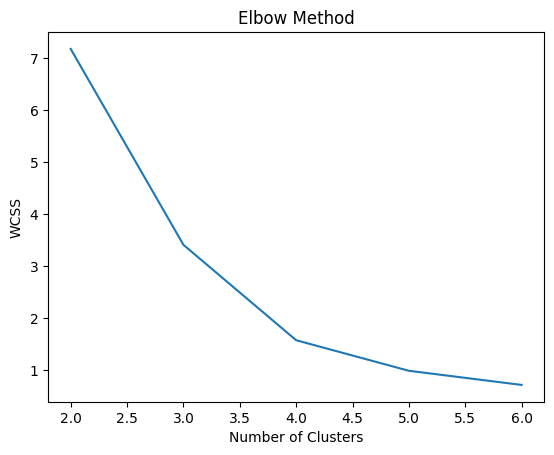

   student_id  GPA  study_hours  attendance_rate  Cluster
0           1  3.5           15               90        1
1           2  2.8            8               70        2
2           3  3.9           20               95        1
3           4  1.8            5               60        0
4           5  2.5           10               75        2
5           6  3.2           12               85        1
6           7  3.8           18               92        1
7           8  2.0            6               65        0
8           9  2.9            9               80        2
9          10  3.6           16               88        1


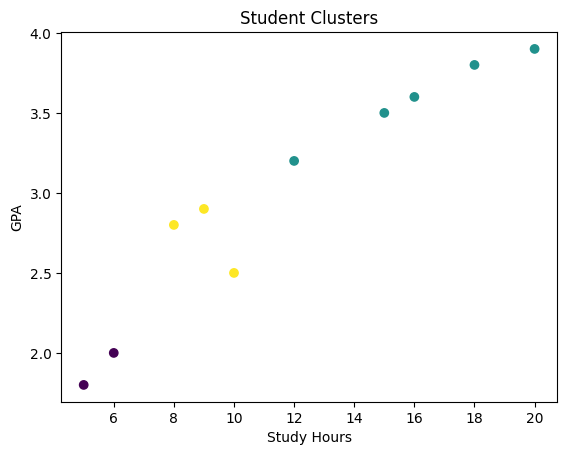

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

data = {
    'student_id': [1,2,3,4,5,6,7,8,9,10],
    'GPA': [3.5, 2.8, 3.9, 1.8, 2.5, 3.2, 3.8, 2.0, 2.9, 3.6],
    'study_hours': [15, 8, 20, 5, 10, 12, 18, 6, 9, 16],
    'attendance_rate': [90, 70, 95, 60, 75, 85, 92, 65, 80, 88]
}

df = pd.DataFrame(data)

X = df[['GPA', 'study_hours', 'attendance_rate']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []

for i in range(2, 7):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(2,7), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df)

plt.scatter(df['study_hours'], df['GPA'], c=df['Cluster'])
plt.xlabel('Study Hours')
plt.ylabel('GPA')
plt.title('Student Clusters')
plt.show()